<a href="https://colab.research.google.com/github/uzumakiinaru/2020-_CALENDAR/blob/main/LecQuiz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 - DATASET FOR DATA CLEANING

In [37]:
import pandas as pd
import numpy as np


messy_data = {
'patient_name': ['Dela Cruz', 'Santos', 'Reyes', 'bautista', 'GARCIA ', ' Mendoza', 'Torres', 'Ramos',
    'Aquino', 'Fernandez', 'delaCruz', 'Santos', 'Villanueva', 'Domingo', 'Castro',
    None, 'Reyes', 'Navarro', None, 'Pascual', 'Torres', 'Aquino', 'Bautista', 'Cruz', 'Mercado'],

'sex': ['M','F','Male','female','M','F','m','F','M','Female','F','M','F','M','F',
    'M','F','M','F','M','F','M','F','M','F'],

'barangay': ['San Roque','Bagumbayan','san roque','Poblacion','Bagumbayan ','San Jose',
    'Poblacion','Sto. Nino','San Roque','Bagumbayan','Poblacion','San Jose',
    'Sto Nino','San Roque','Bagumbayan','Poblacion','San Roque','San Jose',
    'Bagumbayan','Poblacion','Sto. Nino','San Roque','San Jose','Bagumbayan','Poblacion'],

'visit_date': ['2026-01-05','01/06/2026','2026-1-7','2026-01-08','08-01-2026','2026-01-09',
    '2026-01-09','2026/01/10','2026-01-11','01-12-2026','2026-01-13','2026-01-13',
    '2026-01-14','2026-01-15',None,'2026-01-16','2026-01-17','2026-01-18',
    '2026-01-19','2026-01-20','2026-01-20','2026-01-21','2026-01-22','2026-01-23','2026-01-24'],

'age': [34, 5, 150, 27, np.nan, 62, 41, 8, np.nan, 29, 34, 5, 71, 45, 19, -3, 55, np.nan, 22, 38, 41, np.nan, 60, 34, 47],

'weight_kg': ['65kg','18.5','58 kg','70.2','80','45.0kg', '150', '20', '55.5', '62', '65kg', '18.5',
    '68', '75', np.nan, '-40', '90kg', '52', '30', '77', '68', '58', '95', '65kg', '61'],

'height_cm': [165, 110, 170, np.nan, 175, 150, 168, 128, 160, 172, 165, 110, 155, 180, 140,
    169, 158, np.nan, 132, 162, 168, 173, 5.9, 165, 159],

'bp_systolic': ['120','95','210','130','118','160','122','100','300','125','120','95','140',
    '135','108','119','150','127','98','131','122','128','145','120','133'],

'temperature_c': [36.5, 37.0, 39.8, 36.7, 36.6, 38.2, 36.9, 36.8, 42.5, 36.5, 36.5, 37.0,
    37.1, 36.4, 36.9, 36.6, 40.1, 36.7, 36.8, 36.9, 36.5, 37.2, 39.0, 36.5, 36.6],

'diagnosis': ['Hypertension','Common Cold','hypertension','Diabetes','COMMON COLD','Flu',
    'Hypertension ','Asthma','Diabetes Type 2','common cold','Hypertension','Common Cold',
    'Migraine','Flu','UTI','Hypertension','diabetes','Asthma','Common Cold','Flu',
    'Hypertension','Diabetes','Migrain','Hypertension','UTI'],

'follow_up_needed': ['Yes','No','yes','NO','Y','N','Yes','No','yes','No','Yes','No','No',
    'Yes','No','Yes','yes','No','N','Yes','Yes','No','Y','Yes','No'],

'senior_citizen': [0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0]
}

df_messy = pd.DataFrame(messy_data)
missing_name = df_messy[df_messy['patient_name'].isnull()]
duplicate = df_messy[df_messy.duplicated(subset = ['patient_name'], keep = 'first')]
missing_date = df_messy[df_messy['visit_date'].isnull()]
missing_age = df_messy[df_messy['age'].isnull()]
missing_weight = df_messy[df_messy['weight_kg'].isnull()]
missing_height = df_messy[df_messy['height_cm'].isnull()]




problem_rows = pd.concat([missing_name, duplicate, missing_date, missing_weight])
print(problem_rows)

   patient_name sex    barangay  visit_date   age weight_kg  height_cm  \
15         None   M   Poblacion  2026-01-16  -3.0       -40      169.0   
18         None   F  Bagumbayan  2026-01-19  22.0        30      132.0   
11       Santos   M    San Jose  2026-01-13   5.0      18.5      110.0   
16        Reyes   F   San Roque  2026-01-17  55.0      90kg      158.0   
18         None   F  Bagumbayan  2026-01-19  22.0        30      132.0   
20       Torres   F   Sto. Nino  2026-01-20  41.0        68      168.0   
21       Aquino   M   San Roque  2026-01-21   NaN        58      173.0   
14       Castro   F  Bagumbayan        None  19.0       NaN      140.0   
14       Castro   F  Bagumbayan        None  19.0       NaN      140.0   

   bp_systolic  temperature_c     diagnosis follow_up_needed  senior_citizen  
15         119           36.6  Hypertension              Yes               0  
18          98           36.8   Common Cold                N               0  
11          95        

STEP 2 - CHECK FOR MISSING VALUES

In [ ]:
print("Missing Values[per column]")
print(df_messy.isnull().sum())

Missing Values[per column]
patient_name        2
sex                 0
barangay            0
visit_date          1
age                 4
weight_kg           1
height_cm           2
bp_systolic         0
temperature_c       0
diagnosis           0
follow_up_needed    0
senior_citizen      0
dtype: int64


STEP 3 - REMOVE ROWS WITH MISSING VALUES

In [38]:
df_clean = df_messy.dropna(subset=['patient_name','age','height_cm','visit_date','weight_kg' ])
print(df_clean)

   patient_name     sex    barangay  visit_date    age weight_kg  height_cm  \
0     Dela Cruz       M   San Roque  2026-01-05   34.0      65kg      165.0   
1        Santos       F  Bagumbayan  01/06/2026    5.0      18.5      110.0   
2         Reyes    Male   san roque    2026-1-7  150.0     58 kg      170.0   
5       Mendoza       F    San Jose  2026-01-09   62.0    45.0kg      150.0   
6        Torres       m   Poblacion  2026-01-09   41.0       150      168.0   
7         Ramos       F   Sto. Nino  2026/01/10    8.0        20      128.0   
9     Fernandez  Female  Bagumbayan  01-12-2026   29.0        62      172.0   
10     delaCruz       F   Poblacion  2026-01-13   34.0      65kg      165.0   
11       Santos       M    San Jose  2026-01-13    5.0      18.5      110.0   
12   Villanueva       F    Sto Nino  2026-01-14   71.0        68      155.0   
13      Domingo       M   San Roque  2026-01-15   45.0        75      180.0   
16        Reyes       F   San Roque  2026-01-17   55

STEP 4 - REMOVE DUPLICATE ROWS

In [ ]:
df_clean = df_clean.drop_duplicates(subset=['patient_name'])
print(df_clean)

   patient_name     sex     barangay  visit_date    age weight_kg  height_cm  \
0     Dela Cruz       M    San Roque  2026-01-05   34.0      65kg      165.0   
1        Santos       F   Bagumbayan  01/06/2026    5.0      18.5      110.0   
2         Reyes    Male    san roque    2026-1-7  150.0     58 kg      170.0   
3      bautista  female    Poblacion  2026-01-08   27.0      70.2        NaN   
4       GARCIA        M  Bagumbayan   08-01-2026    NaN        80      175.0   
5       Mendoza       F     San Jose  2026-01-09   62.0    45.0kg      150.0   
6        Torres       m    Poblacion  2026-01-09   41.0       150      168.0   
7         Ramos       F    Sto. Nino  2026/01/10    8.0        20      128.0   
8        Aquino       M    San Roque  2026-01-11    NaN      55.5      160.0   
9     Fernandez  Female   Bagumbayan  01-12-2026   29.0        62      172.0   
10     delaCruz       F    Poblacion  2026-01-13   34.0      65kg      165.0   
12   Villanueva       F     Sto Nino  20

STEP 5 - VALIDATE DATA RANGES

In [ ]:
print("Age Data Range: ", df_clean['age'].min(), "-" ,df_clean['age'].max() )
print("Weight Data Range: ", df_clean['weight_kg'].min(), "-" ,df_clean['weight_kg'].max() )
print("Height Data Range: ", df_clean['height_cm'].min(), "-" ,df_clean['height_cm'].max() )
print("BP Data Range: ", df_clean['bp_systolic'].min(), "-" ,df_clean['bp_systolic'].max() )
print("Temperature Data Range: ", df_clean['temperature_c'].min(), "-" ,df_clean['temperature_c'].max() )
print("Senior Data Range: ", df_clean['senior_citizen'].min(), "-" ,df_clean['senior_citizen'].max() )


Age Data Range:  5.0 - 150.0
Weight Data Range:  150 - 95
Height Data Range:  5.9 - 180.0
BP Data Range:  100 - 95
Temperature Data Range:  36.4 - 42.5
Senior Data Range:  0 - 1


STEP 6 - FINAL CLEAN DATA


In [ ]:
print("Clean Data")
print(df_clean)

Clean Data
   patient_name     sex     barangay  visit_date    age weight_kg  height_cm  \
0     Dela Cruz       M    San Roque  2026-01-05   34.0      65kg      165.0   
1        Santos       F   Bagumbayan  01/06/2026    5.0      18.5      110.0   
2         Reyes    Male    san roque    2026-1-7  150.0     58 kg      170.0   
3      bautista  female    Poblacion  2026-01-08   27.0      70.2        NaN   
4       GARCIA        M  Bagumbayan   08-01-2026    NaN        80      175.0   
5       Mendoza       F     San Jose  2026-01-09   62.0    45.0kg      150.0   
6        Torres       m    Poblacion  2026-01-09   41.0       150      168.0   
7         Ramos       F    Sto. Nino  2026/01/10    8.0        20      128.0   
8        Aquino       M    San Roque  2026-01-11    NaN      55.5      160.0   
9     Fernandez  Female   Bagumbayan  01-12-2026   29.0        62      172.0   
10     delaCruz       F    Poblacion  2026-01-13   34.0      65kg      165.0   
12   Villanueva       F     S

STEP 7 -  DATA VISUALIZATION

<function matplotlib.pyplot.show(close=None, block=None)>

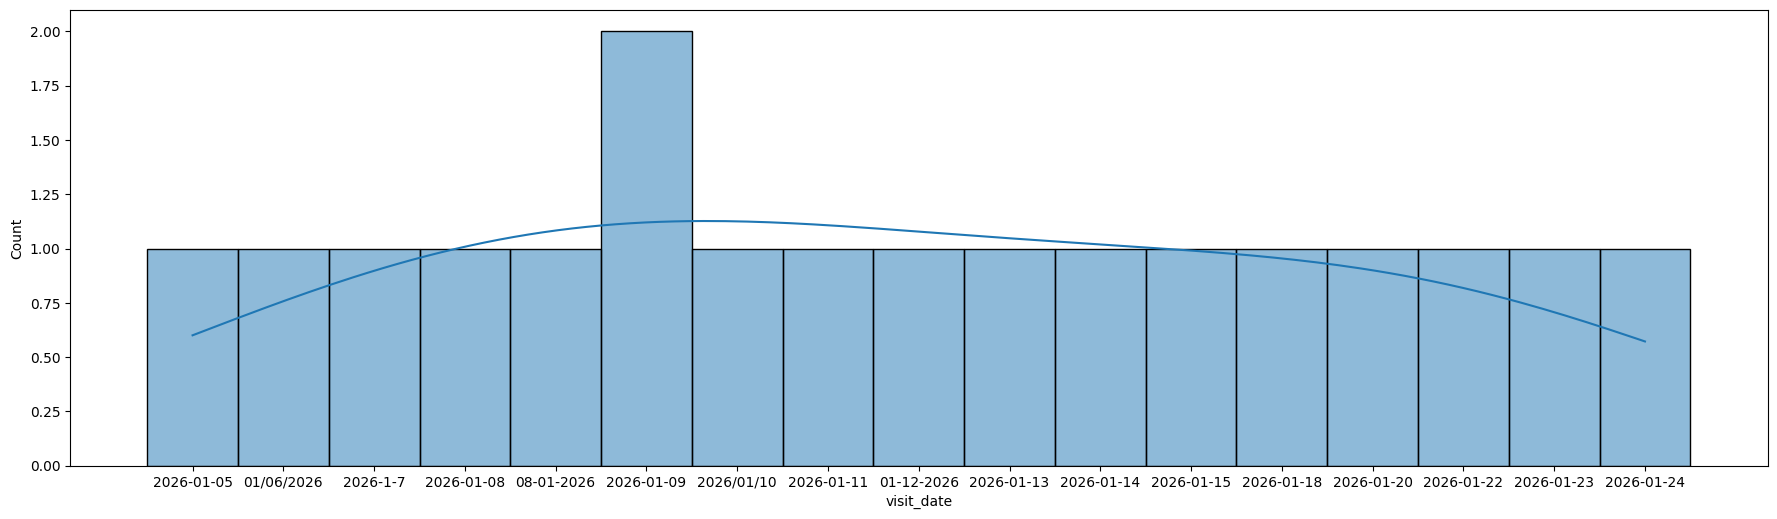

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(35,10))

plt.subplot(2,2,1)
sns.histplot(df_clean['visit_date'], kde = True)

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

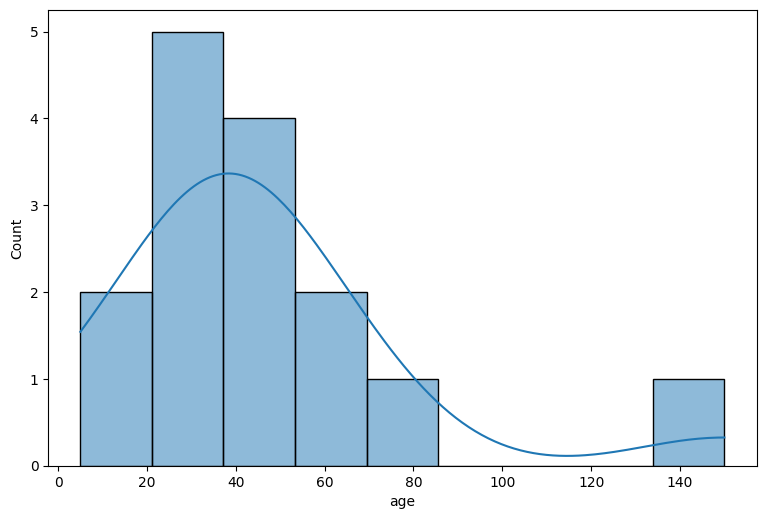

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)

sns.histplot(df_clean['age'], kde = True)

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

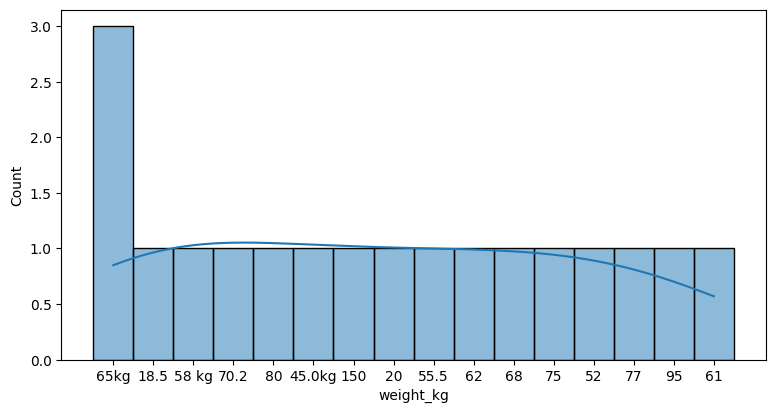

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))

plt.subplot(2,2,1)

sns.histplot(df_clean['weight_kg'], kde = True)

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

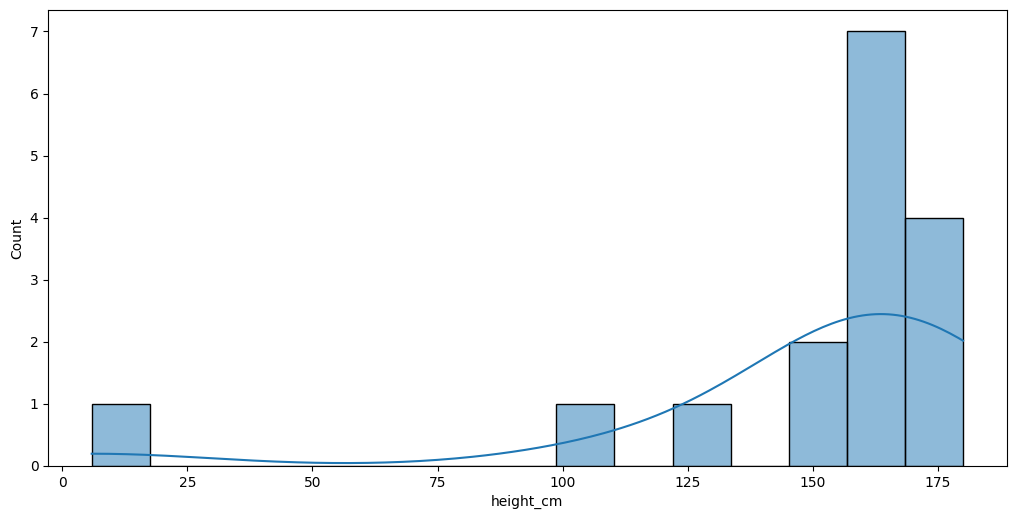

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
sns.histplot(df_clean['height_cm'], kde = True)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

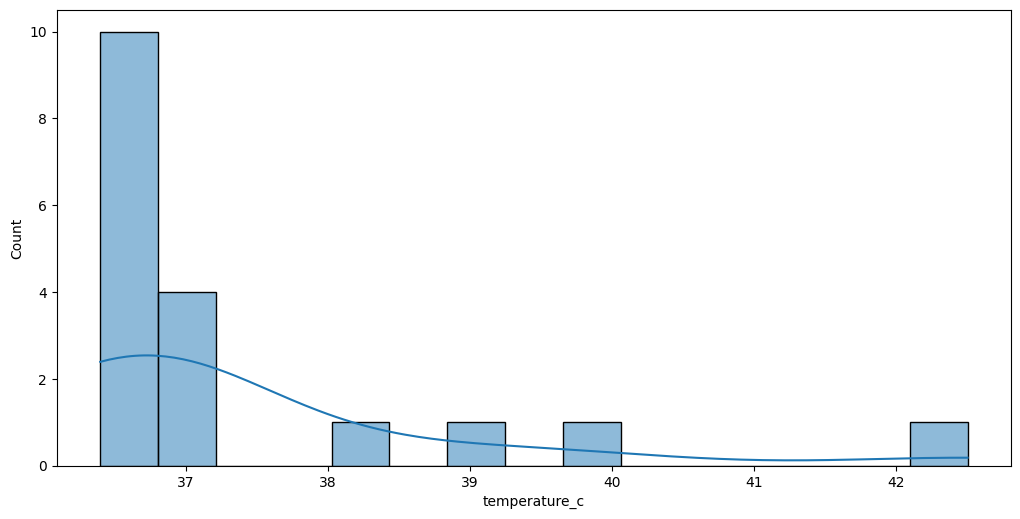

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
sns.histplot(df_clean['temperature_c'], kde = True)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

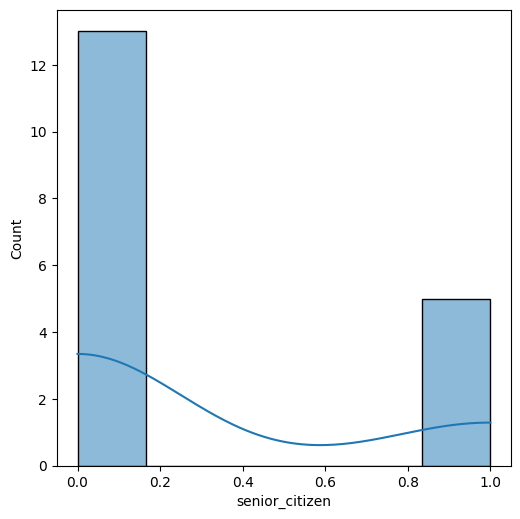

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

plt.subplot(2,2,1)

sns.histplot(df_clean['senior_citizen'], kde = True)
plt.tight_layout()
plt.show

**Aswer the FF questions:**

1. List every column that contains missing values and report how many missing values each one has.

2. A patient record is missing  patient_name  entirely. Can this row still be useful for analyzing illness patterns or vital sign trends? Explain.

3. The  barangay  column has entries like  San Roque ,  san roque ,  Sto. Nino , and  Sto Nino . How many unique barangays actually exist in this dataset once formatting is standardized, versus how many appear before cleaning?
4. After cleaning the dates, sort the dataset by  visit_date . Were there any days with more than one patient visit? Which day had the most visits?
5. Not all repeated names are true duplicates. How would you distinguish a returning patient’s second real visit from an accidental double-encoded entry? What additional column would help you decide?
6. After all cleaning steps, produce a final  df_clean  and report: total valid patients, average age, most common diagnosis, and percentage needing follow-up.
7. Look at the  patient_name ,  age , and  barangay  columns together. Which rows look like they might be duplicate entries for the same patient? What evidence supports that?
8. The  sex  column contains  M ,  Male ,  F ,  female ,  m , and  Female . Write the cleaning logic to reduce this to exactly two consistent labels, and explain how you handled case sensitivity.
9. The  diagnosis  column contains  Migraine  and  Migrain , plus  Diabetes  and  Diabetes Type 2 . Should these be merged into single categories? What is lost or gained by merging  Diabetes  and  Diabetes Type 2 ?
10. Which single data quality issue in this dataset do you think would cause the most harm if left unfixed in a real health center’s reporting system? Explain the real-world consequence.

**ANSWERS**

1. patient_name, visit_date, age, weight_kg, and height_cm
2. Yes, the model still analyze the pattern. The "none" represent the missing name, but the the data for illness/common diagnosis are present. We just dont know whho is the patient behind this.
3. 5 barangays.
4. 2026-01-09, 2026-01-13, and 2026-01-20
5. By checking the visit date, if he diagnosis are the same and he dates aren't, mostly it is the same patient's second real visit.
6. There are 20 valid patients,
   average age is 34
   common diagnosis is hypertension
   10 patients required follow up --50%
   10 patient no follow up        --50%  

7. Though, patients have different name and barangays, this patients is a
   posible duplicate : DelaCruz, and cruz. Why? the age is both 34 and the other detail proves it such as the:
  height_cm - both of them is 165 cm,
  diagnosis - both have hypertension
  follow up - both need follow up

8. i didnt have a clean up for that, i just classify m, male as male and f. female as female.

9. for Migraine/migrain yes. But not in the diabetes. It must be categorized because it have different stages.
10. The incorrect input of diagnosis, inconsistent diagnosis can lead to    incorrect reports or assesments.
   
